# OWT Structural Model with PyDynSM: Part 4



Assumptions:
- dynamic SSI is neglected, so the soil response from question 3 will later act as the kinematic base excitation of the OWT
- the base of the OWT is rigidly connected to the ground surface
- the lower tower segment has length `H_w` and uses diameter set 1
- the upper tower segment has length `H_t - H_w` and uses diameter set 2
- the concentrated mass `M` and rotational inertia `J` are attached at the tower top


In [1]:
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pydynsm as PDM
from scipy import optimize as opt
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


## 1. Problem Values


In [2]:
# Student-ID digits used throughout the assignment
A = 6
B = 6
C = 1
D = 1
E = 2
F = 5
G = 7

# Structural properties
M = (800 + 10 * F) * 1e3      # kg, 8F0 * 10^3
J = 300 * 1e6                 # kg m^2
rho_t = 7850.0                # kg/m^3
E_t = 210e9                   # Pa
xi_t = 0.001                  # -

D_out_1 = 9.1                 # m
D_inner_1 = 8.96              # m
D_out_2 = 7.1                 # m
D_inner_2 = 7.0               # m

F_w = 2e5                     # N
H_t = 140 + A                 # m
H_w = 30 + F                  # m

# Soil properties kept for consistency with the earlier notebooks
H_1 = 2 + B                   # m
H_2 = 58 + G                  # m
H_3 = 38 + F                  # m

G_1 = (100 + 10 * F) * 1e6    # Pa
rho_1 = 1650.0                # kg/m^3
eta_1 = (1000 + 10 * C)       # Ns/m^2

G_2 = (100 + 10 * D) * 1e6    # Pa
rho_2 = 1850.0                # kg/m^3
eta_2 = (1000 + 10 * E)       # Ns/m^2

G_3 = (100 + 10 * E) * 1e6    # Pa
rho_3 = 1900.0                # kg/m^3
eta_3 = (1000 + 10 * D)       # Ns/m^2

print("Student-ID digits:", {"A": A, "B": B, "C": C, "D": D, "E": E, "F": F, "G": G})
print(f"M = {M:,.0f} kg")
print(f"J = {J:,.0f} kg m^2")
print(f"H_t = {H_t:.1f} m")
print(f"H_w = {H_w:.1f} m")
print(f"Tower split: lower = {H_w:.1f} m, upper = {H_t - H_w:.1f} m")


Student-ID digits: {'A': 6, 'B': 6, 'C': 1, 'D': 1, 'E': 2, 'F': 5, 'G': 7}
M = 850,000 kg
J = 300,000,000 kg m^2
H_t = 146.0 m
H_w = 35.0 m
Tower split: lower = 35.0 m, upper = 111.0 m


In [3]:
def tube_section_properties(d_outer, d_inner):
    area = np.pi / 4.0 * (d_outer**2 - d_inner**2)
    inertia = np.pi / 64.0 * (d_outer**4 - d_inner**4)
    section_modulus = inertia / (d_outer / 2.0)
    return area, inertia, section_modulus


A_t1, I_t1, W_t1 = tube_section_properties(D_out_1, D_inner_1)
A_t2, I_t2, W_t2 = tube_section_properties(D_out_2, D_inner_2)

L_lower = float(H_w)
L_upper = float(H_t - H_w)

print("Lower segment properties:")
print(f"  A_1 = {A_t1:.6f} m^2")
print(f"  I_1 = {I_t1:.6f} m^4")
print(f"  W_1 = {W_t1:.6f} m^3")
print()
print("Upper segment properties:")
print(f"  A_2 = {A_t2:.6f} m^2")
print(f"  I_2 = {I_t2:.6f} m^4")
print(f"  W_2 = {W_t2:.6f} m^3")


Lower segment properties:
  A_1 = 1.985801 m^2
  I_1 = 20.241714 m^4
  W_1 = 4.448728 m^3

Upper segment properties:
  A_2 = 1.107411 m^2
  I_2 = 6.880486 m^4
  W_2 = 1.938165 m^3


## 2. OWT Beam Model

For the lateral in-plane response of the tower, the OWT is modeled with `EulerBernoulli Beam foundation attachments`.

Only the lateral translation and bending rotation are needed, so each node uses the DOFs

`['x', 'phi_y']`.

The nodal coordinates are:
- node 0: base at `z = 0`
- node 1: diameter change at `z = H_w`
- node 2: tower top at `z = H_t`

The base node is fixed for the free-vibration check. Later, in the forced-response part, the same base horizontal DOF can be prescribed to the ground-surface motion obtained from the soil model.


In [4]:
def build_owt_structure(ksi=xi_t):
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        structure = PDM.Assembler("OWT beam model")

        nodes = [
            structure.CreateNode(0.0, 0.0, dof_config=["x", "phi_y"]),
            structure.CreateNode(0.0, L_lower, dof_config=["x", "phi_y"]),
            structure.CreateNode(0.0, H_t, dof_config=["x", "phi_y"]),
        ]

        elements = [
            structure.CreateElement([nodes[0], nodes[1]]),
            structure.CreateElement([nodes[1], nodes[2]]),
        ]

        elements[0].SetSection(
            "EulerBernoulli Beam foundation attachments",
            {
                "rho": rho_t,
                "A": A_t1,
                "E": E_t,
                "Ib": I_t1,
                "Wb": W_t1,
                "L": L_lower,
                "kd": 0.0,
                "cd": 0.0,
                "ksi": ksi,
            },
        )

        elements[1].SetSection(
            "EulerBernoulli Beam foundation attachments",
            {
                "rho": rho_t,
                "A": A_t2,
                "E": E_t,
                "Ib": I_t2,
                "Wb": W_t2,
                "L": L_upper,
                "kd": 0.0,
                "cd": 0.0,
                "Pm2": M,
                "J2": J,
                "ksi": ksi,
            },
        )

        nodes[0].fix_node("x", "phi_y")
        structure.run_connectivity()

    return structure, nodes, elements


def constrained_matrix(structure, omega):
    return structure.GlobalConstrainedStiffness(float(omega))


def smallest_singular_value(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    return float(np.min(np.linalg.svd(K_ff, compute_uv=False)))


def find_natural_frequencies(
    structure,
    omega_min=0.01,
    omega_max=60.0,
    n_scan=5000,
    n_modes=4,
):
    omega_scan = np.linspace(omega_min, omega_max, n_scan)
    sigma_scan = np.array([smallest_singular_value(structure, omega) for omega in omega_scan])

    indicator = -np.log10(np.maximum(sigma_scan, 1e-30))
    peak_indices, _ = find_peaks(
        indicator,
        prominence=0.5,
        distance=max(50, n_scan // 100),
    )
    peak_indices = peak_indices[np.argsort(omega_scan[peak_indices])]

    omega_n = []
    for idx in peak_indices:
        left = omega_scan[max(idx - 15, 0)]
        right = omega_scan[min(idx + 15, n_scan - 1)]
        result = opt.minimize_scalar(
            lambda w: smallest_singular_value(structure, w),
            bounds=(left, right),
            method="bounded",
        )

        if omega_n and abs(result.x - omega_n[-1]) < 1e-3:
            continue

        omega_n.append(float(result.x))

        if len(omega_n) == n_modes:
            break

    return omega_scan, sigma_scan, np.array(omega_n)


def mode_vector(structure, omega):
    K_ff = constrained_matrix(structure, omega)
    _, _, vh = np.linalg.svd(K_ff)
    phi_free = vh[-1, :].astype(complex)

    reference_index = int(np.argmax(np.abs(phi_free)))
    phi_free = phi_free / phi_free[reference_index]

    if np.real(phi_free[-2]) < 0:
        phi_free = -phi_free

    return phi_free


def mode_profile(structure, omega, num_points_per_element=250):
    phi_free = mode_vector(structure, omega)
    u_full = structure.FullDisplacement(phi_free)
    element_displacements = structure.ElementDisplacements(
        u_full,
        omega,
        num_points=num_points_per_element,
        local_axes=True,
    )

    height_parts = []
    horizontal_parts = []

    for element in structure.elements:
        z_left = element.nodes[0].z
        z_right = element.nodes[1].z
        z_plot = np.linspace(z_left, z_right, num_points_per_element)
        x_plot = np.asarray(np.real_if_close(element_displacements[element.id][1]), dtype=complex)

        if height_parts:
            z_plot = z_plot[1:]
            x_plot = x_plot[1:]

        height_parts.append(z_plot)
        horizontal_parts.append(x_plot)

    height = np.concatenate(height_parts)
    horizontal = np.concatenate(horizontal_parts)

    max_abs = np.max(np.abs(horizontal))
    if max_abs > 0:
        horizontal = horizontal / max_abs

    if np.real(horizontal[-1]) < 0:
        horizontal = -horizontal

    return height, np.real_if_close(horizontal), u_full


## 3. Model Check and Natural Frequencies


Node coordinates [x, z] in m:
  node 0: [0.0, 0.0]
  node 1: [0.0, 35.0]
  node 2: [0.0, 146.0]

Free DOFs: [2 3 4 5]
Constrained DOFs: {0: 0, 1: 0}

First structural natural frequencies:
  mode 1: omega = 1.383447 rad/s,  f = 0.220183 Hz
  mode 2: omega = 9.015489 rad/s,  f = 1.434860 Hz
  mode 3: omega = 21.071031 rad/s,  f = 3.353559 Hz
  mode 4: omega = 43.259223 rad/s,  f = 6.884919 Hz


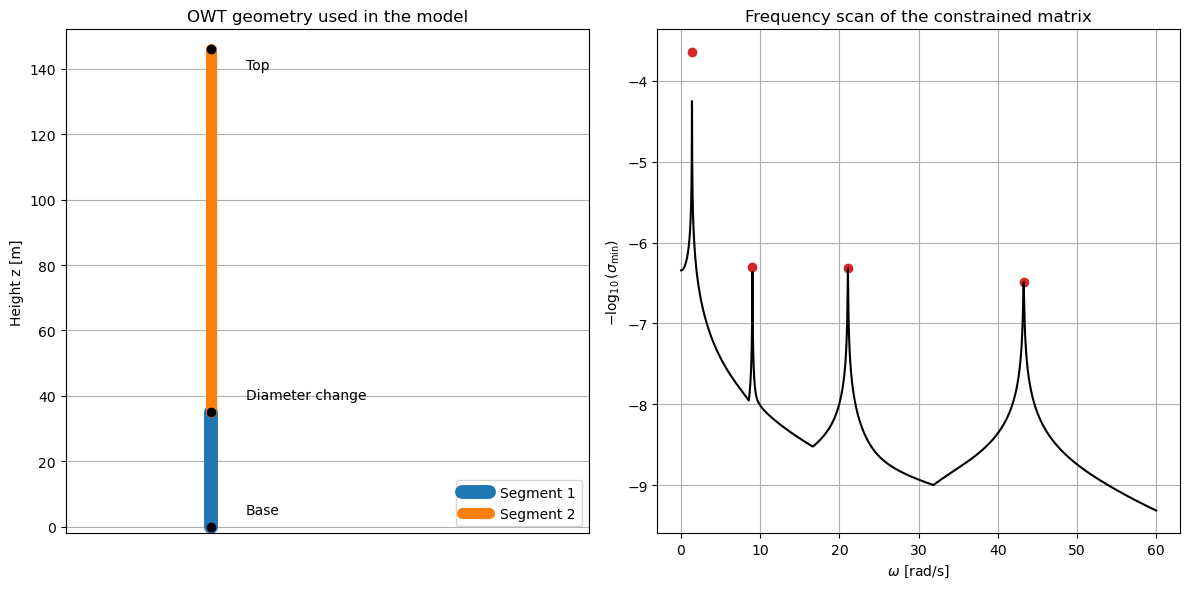

In [5]:
owt, owt_nodes, owt_elements = build_owt_structure()
omega_scan, sigma_scan, omega_n = find_natural_frequencies(owt)
f_n = omega_n / (2.0 * np.pi)

print("Node coordinates [x, z] in m:")
for i, node in enumerate(owt_nodes):
    print(f"  node {i}: [{node.x:.1f}, {node.z:.1f}]")

print()
print("Free DOFs:", owt.Analysis.free_dofs)
print("Constrained DOFs:", owt.Analysis.constrained_dofs)
print()
print("First structural natural frequencies:")
for i, (omega_i, freq_i) in enumerate(zip(omega_n, f_n), start=1):
    print(f"  mode {i}: omega = {omega_i:.6f} rad/s,  f = {freq_i:.6f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot([0.0, 0.0], [0.0, L_lower], color="tab:blue", lw=10, solid_capstyle="round", label="Segment 1")
axes[0].plot([0.0, 0.0], [L_lower, H_t], color="tab:orange", lw=8, solid_capstyle="round", label="Segment 2")
axes[0].scatter([0.0, 0.0, 0.0], [0.0, L_lower, H_t], color="black", zorder=3)
axes[0].annotate("Base", (0.0, 0.0), xytext=(0.12, 4.0))
axes[0].annotate("Diameter change", (0.0, L_lower), xytext=(0.12, L_lower + 4.0))
axes[0].annotate("Top", (0.0, H_t), xytext=(0.12, H_t - 6.0))
axes[0].set_xlim(-0.5, 1.3)
axes[0].set_ylim(-2.0, H_t + 6.0)
axes[0].set_xticks([])
axes[0].set_ylabel("Height z [m]")
axes[0].set_title("OWT geometry used in the model")
axes[0].legend(loc="lower right")

indicator = -np.log10(np.maximum(sigma_scan, 1e-30))
axes[1].plot(omega_scan, indicator, color="black")
axes[1].scatter(omega_n, -np.log10(np.maximum([smallest_singular_value(owt, w) for w in omega_n], 1e-30)), color="tab:red")
axes[1].set_xlabel(r"$\omega$ [rad/s]")
axes[1].set_ylabel(r"$-\log_{10}(\sigma_{\min})$")
axes[1].set_title("Frequency scan of the constrained matrix")

plt.tight_layout()
plt.show()


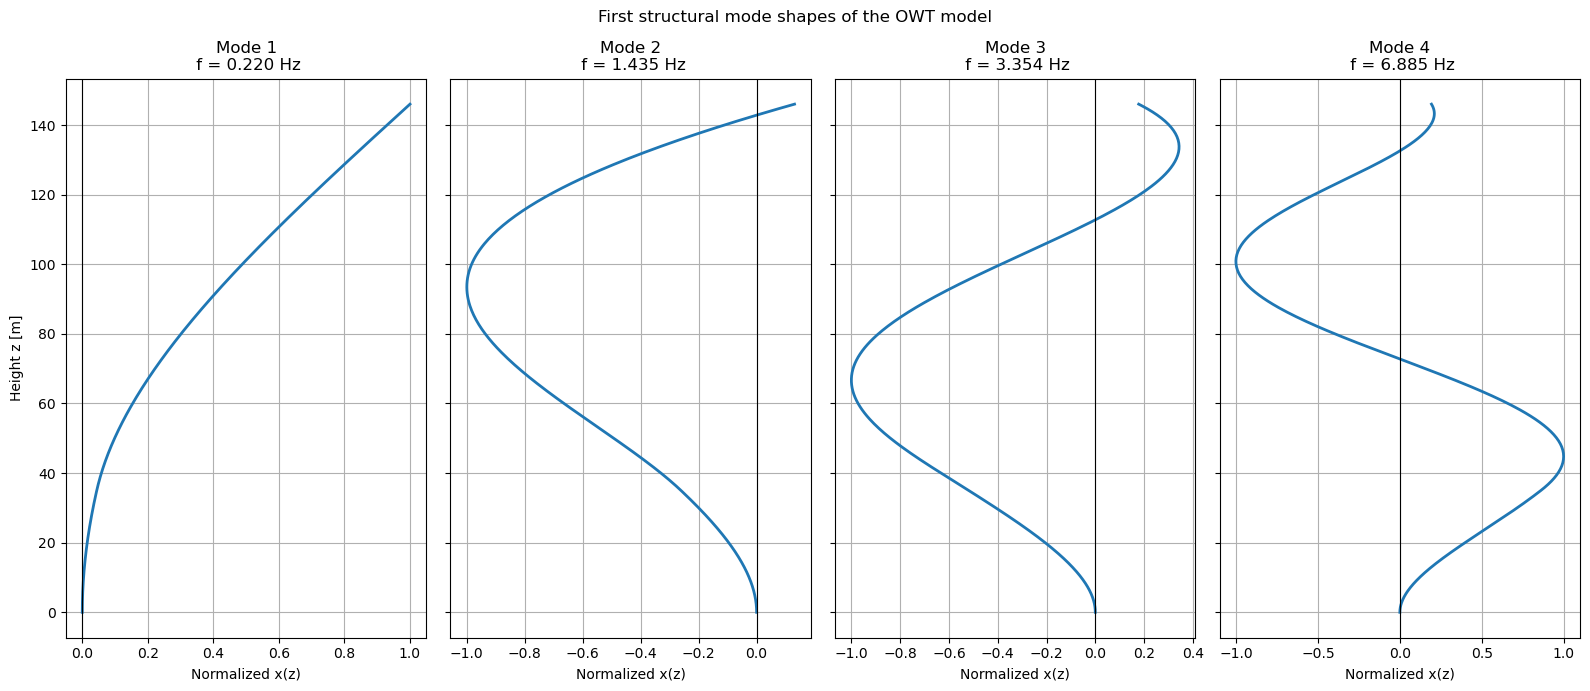

In [6]:
fig, axes = plt.subplots(1, len(omega_n), figsize=(4 * len(omega_n), 7), sharey=True)

for i, omega_i in enumerate(omega_n):
    height_i, horizontal_i, _ = mode_profile(owt, omega_i)
    axes[i].plot(np.real(horizontal_i), height_i, color="tab:blue", lw=2)
    axes[i].axvline(0.0, color="black", lw=0.8)
    axes[i].set_title(f"Mode {i + 1}\n f = {f_n[i]:.3f} Hz")
    axes[i].set_xlabel("Normalized x(z)")

axes[0].set_ylabel("Height z [m]")
fig.suptitle("First structural mode shapes of the OWT model")
fig.tight_layout()
plt.show()


## 4. Response Quantities for Later Parts

For this 3-node and 2-DOF-per-node model, `FullDisplacement` returns

`[base_x, base_phi_y, mid_x, mid_phi_y, top_x, top_phi_y]`.

The response quantities required later are:
- top displacement: horizontal displacement at the top node
- base bending moment: bending moment of element 0 at `s = 0`

For the seismic case, the base horizontal displacement will later be prescribed from the soil-surface motion obtained in question 3, while the base rotation remains zero.


In [7]:
def solve_base_excited_owt(structure, omega, U_base=1.0):
    omega = float(omega)
    K_global = structure.GlobalStiffness(omega)
    free = structure.Analysis.free_dofs
    constrained = np.array(list(structure.Analysis.constrained_dofs.keys()), dtype=int)

    # Prescribe horizontal base motion and keep the base rotation fixed.
    u_constrained = np.array([U_base, 0.0], dtype=complex)

    K_ff = K_global[np.ix_(free, free)]
    K_fc = K_global[np.ix_(free, constrained)]
    u_free = np.linalg.solve(K_ff, -(K_fc @ u_constrained))

    return structure.FullDisplacement(u_free)


def owt_response_quantities(structure, u_full, omega):
    element_forces = structure.ElementForces(u_full, float(omega), num_points=2)
    base_element_id = structure.elements[0].id
    return {
        "top_displacement": u_full[4],
        "base_shear": element_forces[base_element_id][1][0],
        "base_bending_moment": element_forces[base_element_id][5][0],
    }


omega_demo = 1.0
u_demo = solve_base_excited_owt(owt, omega_demo, U_base=1.0)
response_demo = owt_response_quantities(owt, u_demo, omega_demo)

print(f"Demo response at omega = {omega_demo:.1f} rad/s for U_base = 1.0 m:")
for key, value in response_demo.items():
    print(f"  {key}: {value}")


Demo response at omega = 1.0 rad/s for U_base = 1.0 m:
  top_displacement: (2.210623399172299-0.005072784880601881j)
  base_shear: (-1193430473.4904277-2372928.435255985j)
  base_bending_moment: (21252094868.25678+40752322.25557701j)


## 5. Responses to the Different Load Cases

For part 4.1 it is useful to compute the response to each load case separately before combining spectra:

- **constant wind force** at the tower top: static mean response
- **seismic excitation**: dynamic response to the ground-surface motion from the soil notebook
- **wave excitation**: dynamic response to the Morison inertia load derived from the JONSWAP spectrum

The arrays produced in `wave_earthquake_psd.ipynb` are loaded from `part41_input_psd.npz`.

In [8]:
from pathlib import Path

part41_input = np.load(Path("part41_input_psd.npz"), allow_pickle=True)

omega_seismic = np.asarray(part41_input["omega_seismic"], dtype=float)
f_seismic = omega_seismic / (2.0 * np.pi)
Su_surface_omega = np.asarray(part41_input["seismic_surface_disp_psd_omega"], dtype=float)
Sa_surface_omega = np.asarray(part41_input["seismic_surface_accel_psd_omega"], dtype=float)
H_soil_surface = np.asarray(part41_input["soil_surface_transfer_complex"], dtype=complex)

omega_wave = np.asarray(part41_input["omega_wave"], dtype=float)
f_wave = omega_wave / (2.0 * np.pi)
S_eta_omega = np.asarray(part41_input["jonswap_surface_elevation_psd_omega"], dtype=float)
wave_y = np.asarray(part41_input["wave_y_from_mudline"], dtype=float)
H_eta_to_q = np.asarray(part41_input["wave_force_transfer_per_length"], dtype=complex)

print("Loaded part 4.1 input arrays:")
print(f"  seismic frequencies: {f_seismic[0]:.3f} to {f_seismic[-1]:.3f} Hz ({f_seismic.size} points)")
print(f"  wave frequencies: {f_wave[0]:.3f} to {f_wave[-1]:.3f} Hz ({f_wave.size} points)")
print(f"  wave-load depth points on the lower segment: {wave_y.size}")


Loaded part 4.1 input arrays:
  seismic frequencies: 0.020 to 15.000 Hz (4000 points)
  wave frequencies: 0.020 to 2.000 Hz (2500 points)
  wave-load depth points on the lower segment: 81


In [9]:
def solve_force_excited_owt(structure, omega, force_full):
    omega = float(omega)
    K_global = structure.GlobalStiffness(omega)
    free = np.array(structure.Analysis.free_dofs, dtype=int)

    force_full = np.asarray(force_full, dtype=complex).reshape(-1)
    u_free = np.linalg.solve(K_global[np.ix_(free, free)], force_full[free])
    return structure.FullDisplacement(u_free)


def wind_force_vector_top(F_top):
    force = np.zeros(6, dtype=complex)
    force[4] = F_top
    return force


def hermite_shape_functions(y, L):
    xi = np.asarray(y, dtype=float) / float(L)
    N1 = 1.0 - 3.0 * xi**2 + 2.0 * xi**3
    N2 = L * (xi - 2.0 * xi**2 + xi**3)
    N3 = 3.0 * xi**2 - 2.0 * xi**3
    N4 = L * (-xi**2 + xi**3)
    return np.vstack([N1, N2, N3, N4])


def lower_segment_wave_force_vector(q_profile, y_profile, L_element=L_lower):
    q_profile = np.asarray(q_profile, dtype=complex)
    y_profile = np.asarray(y_profile, dtype=float)

    N = hermite_shape_functions(y_profile, L_element)
    local_force = np.array([
        np.trapezoid(N[i] * q_profile, y_profile) for i in range(4)
    ], dtype=complex)

    full_force = np.zeros(6, dtype=complex)
    full_force[0:4] = local_force
    return full_force, local_force


owt_static, _, _ = build_owt_structure(ksi=0.0)
omega_static = 1e-6
u_wind = solve_force_excited_owt(owt_static, omega_static, wind_force_vector_top(F_w))
response_wind = owt_response_quantities(owt_static, u_wind, omega_static)

print("Static wind response from the constant top force F_w (real static limit):")
for key, value in response_wind.items():
    print(f"  {key}: {np.real(value)}")


Static wind response from the constant top force F_w (real static limit):
  top_displacement: -0.09173003536697617
  base_shear: 209427.9576727407
  base_bending_moment: -30575892.179238293


### 5.1 Seismic Load Case

The seismic case uses the surface displacement PSD from the soil notebook as the input PSD at the tower base. Since the base displacement amplitude is set to `1 m` in the transfer calculation, the complex responses below are directly the FRFs

- `top displacement / base displacement`
- `base moment / base displacement`

Largest seismic top-displacement PSD contribution near f = 0.215 Hz
  |H_u| = 2.2754e+01 m/m
  |H_M| = 2.8145e+10 Nm/m


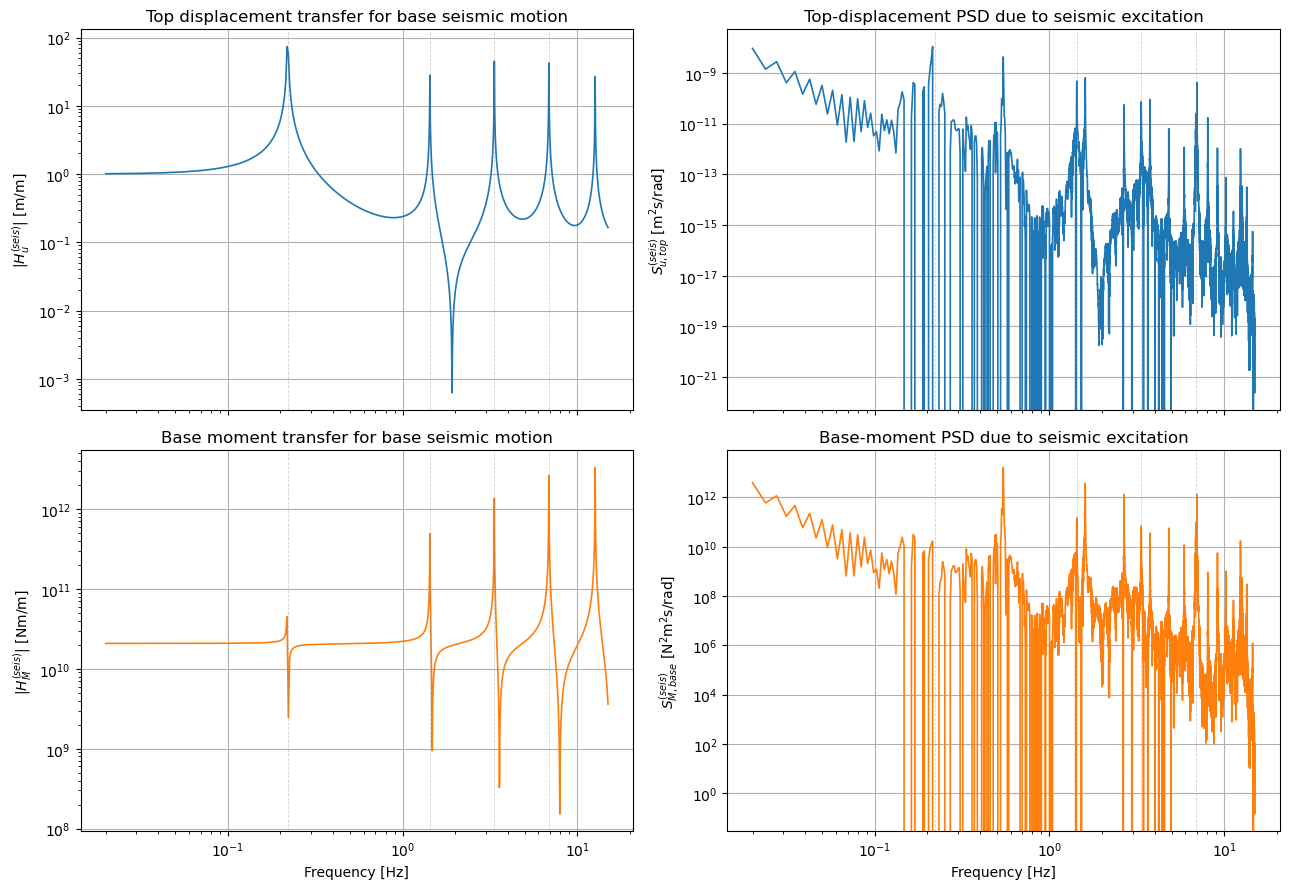

In [10]:
H_u_top_seismic = np.zeros_like(omega_seismic, dtype=complex)
H_M_base_seismic = np.zeros_like(omega_seismic, dtype=complex)

for i, omega in enumerate(omega_seismic):
    u_full_i = solve_base_excited_owt(owt, omega, U_base=1.0)
    response_i = owt_response_quantities(owt, u_full_i, omega)
    H_u_top_seismic[i] = response_i["top_displacement"]
    H_M_base_seismic[i] = response_i["base_bending_moment"]

S_u_top_seismic = np.abs(H_u_top_seismic) ** 2 * Su_surface_omega
S_M_base_seismic = np.abs(H_M_base_seismic) ** 2 * Su_surface_omega

idx_peak_seismic = int(np.argmax(S_u_top_seismic))
print(f"Largest seismic top-displacement PSD contribution near f = {f_seismic[idx_peak_seismic]:.3f} Hz")
print(f"  |H_u| = {np.abs(H_u_top_seismic[idx_peak_seismic]):.4e} m/m")
print(f"  |H_M| = {np.abs(H_M_base_seismic[idx_peak_seismic]):.4e} Nm/m")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex="col")

axes[0, 0].loglog(f_seismic, np.abs(H_u_top_seismic), color="tab:blue", lw=1.2)
axes[0, 0].set_ylabel(r"$|H_u^{(seis)}|$ [m/m]")
axes[0, 0].set_title("Top displacement transfer for base seismic motion")

axes[1, 0].loglog(f_seismic, np.abs(H_M_base_seismic), color="tab:orange", lw=1.2)
axes[1, 0].set_xlabel("Frequency [Hz]")
axes[1, 0].set_ylabel(r"$|H_M^{(seis)}|$ [Nm/m]")
axes[1, 0].set_title("Base moment transfer for base seismic motion")

axes[0, 1].loglog(f_seismic, S_u_top_seismic, color="tab:blue", lw=1.2)
axes[0, 1].set_ylabel(r"$S_{u,top}^{(seis)}$ [m$^2$s/rad]")
axes[0, 1].set_title("Top-displacement PSD due to seismic excitation")

axes[1, 1].loglog(f_seismic, S_M_base_seismic, color="tab:orange", lw=1.2)
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].set_ylabel(r"$S_{M,base}^{(seis)}$ [N$^2$m$^2$s/rad]")
axes[1, 1].set_title("Base-moment PSD due to seismic excitation")

for ax in axes.ravel():
    for freq_i in f_n:
        ax.axvline(freq_i, color="gray", lw=0.6, ls="--", alpha=0.35)

plt.tight_layout()
plt.show()


### 5.2 Wave Load Case

For the wave case, the input file already contains the complex transfer from unit sea-surface elevation to the distributed Morison inertia load on the submerged lower segment. The load is converted to an equivalent nodal force vector for the lower beam element, and the OWT response is then solved frequency by frequency.

The complex responses below are therefore the FRFs

- `top displacement / surface elevation amplitude`
- `base moment / surface elevation amplitude`

Largest wave top-displacement PSD contribution near f = 0.220 Hz
  |H_u| = 6.1991e+00 m/m
  |H_M| = 2.0499e+09 Nm/m
  Equivalent nodal force at the JONSWAP peak (base_x, base_phi, mid_x, mid_phi):
    [  118645.44033504+0.j  1113612.26070352+0.j  1190112.79929246+0.j
 -3630147.53668168+0.j]


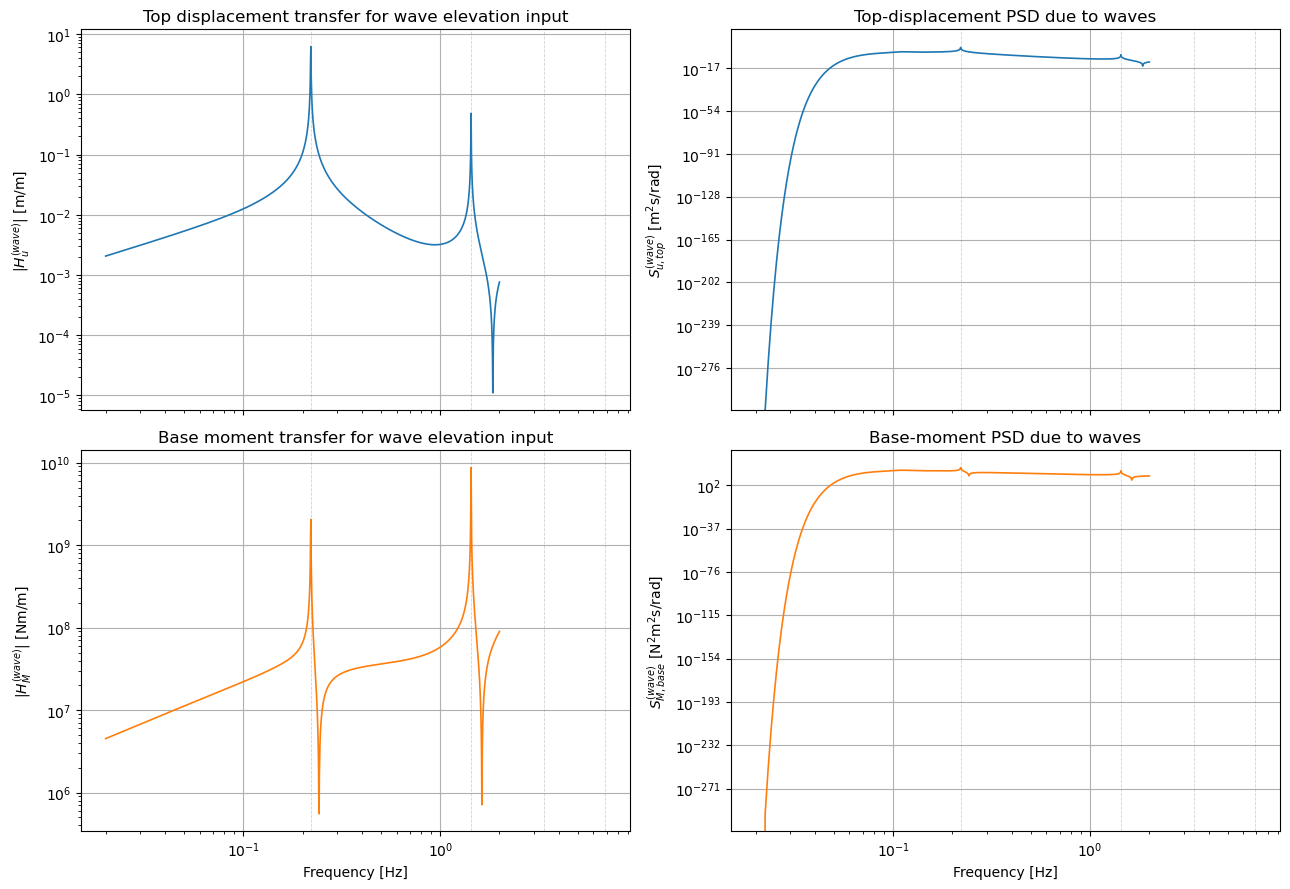

In [11]:
H_u_top_wave = np.zeros_like(omega_wave, dtype=complex)
H_M_base_wave = np.zeros_like(omega_wave, dtype=complex)
wave_force_equiv = np.zeros((omega_wave.size, 4), dtype=complex)

for i, omega in enumerate(omega_wave):
    force_full_i, local_force_i = lower_segment_wave_force_vector(H_eta_to_q[i, :], wave_y)
    u_full_i = solve_force_excited_owt(owt, omega, force_full_i)
    response_i = owt_response_quantities(owt, u_full_i, omega)

    wave_force_equiv[i, :] = local_force_i
    H_u_top_wave[i] = response_i["top_displacement"]
    H_M_base_wave[i] = response_i["base_bending_moment"]

S_u_top_wave = np.abs(H_u_top_wave) ** 2 * S_eta_omega
S_M_base_wave = np.abs(H_M_base_wave) ** 2 * S_eta_omega

idx_peak_wave = int(np.argmax(S_u_top_wave))
print(f"Largest wave top-displacement PSD contribution near f = {f_wave[idx_peak_wave]:.3f} Hz")
print(f"  |H_u| = {np.abs(H_u_top_wave[idx_peak_wave]):.4e} m/m")
print(f"  |H_M| = {np.abs(H_M_base_wave[idx_peak_wave]):.4e} Nm/m")
print(f"  Equivalent nodal force at the JONSWAP peak (base_x, base_phi, mid_x, mid_phi):")
print(f"    {wave_force_equiv[idx_peak_wave, :]}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex="col")

axes[0, 0].loglog(f_wave, np.abs(H_u_top_wave), color="tab:blue", lw=1.2)
axes[0, 0].set_ylabel(r"$|H_u^{(wave)}|$ [m/m]")
axes[0, 0].set_title("Top displacement transfer for wave elevation input")

axes[1, 0].loglog(f_wave, np.abs(H_M_base_wave), color="tab:orange", lw=1.2)
axes[1, 0].set_xlabel("Frequency [Hz]")
axes[1, 0].set_ylabel(r"$|H_M^{(wave)}|$ [Nm/m]")
axes[1, 0].set_title("Base moment transfer for wave elevation input")

axes[0, 1].loglog(f_wave, S_u_top_wave, color="tab:blue", lw=1.2)
axes[0, 1].set_ylabel(r"$S_{u,top}^{(wave)}$ [m$^2$s/rad]")
axes[0, 1].set_title("Top-displacement PSD due to waves")

axes[1, 1].loglog(f_wave, S_M_base_wave, color="tab:orange", lw=1.2)
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].set_ylabel(r"$S_{M,base}^{(wave)}$ [N$^2$m$^2$s/rad]")
axes[1, 1].set_title("Base-moment PSD due to waves")

for ax in axes.ravel():
    for freq_i in f_n:
        ax.axvline(freq_i, color="gray", lw=0.6, ls="--", alpha=0.35)

plt.tight_layout()
plt.show()


## 6. Mean and Variance for Part 4.1

For part 4.1, the response is split into:

- a **mean value** from the constant wind force `F_w`
- a **zero-mean random part** from the seismic and wave loads

Because the assignment states that the wave and seismic PSDs are uncorrelated, the total variance is the sum of the separate variances.

In [12]:
mean_top_displacement = float(np.real(response_wind["top_displacement"]))
mean_base_moment = float(np.real(response_wind["base_bending_moment"]))

var_top_seismic = float(np.trapezoid(S_u_top_seismic, omega_seismic))
var_top_wave = float(np.trapezoid(S_u_top_wave, omega_wave))
var_top_total = var_top_seismic + var_top_wave

var_moment_seismic = float(np.trapezoid(S_M_base_seismic, omega_seismic))
var_moment_wave = float(np.trapezoid(S_M_base_wave, omega_wave))
var_moment_total = var_moment_seismic + var_moment_wave

std_top_seismic = float(np.sqrt(var_top_seismic))
std_top_wave = float(np.sqrt(var_top_wave))
std_top_total = float(np.sqrt(var_top_total))

std_moment_seismic = float(np.sqrt(var_moment_seismic))
std_moment_wave = float(np.sqrt(var_moment_wave))
std_moment_total = float(np.sqrt(var_moment_total))

response_statistics = {
    "top_displacement": {
        "mean": mean_top_displacement,
        "variance_seismic": var_top_seismic,
        "variance_wave": var_top_wave,
        "variance_total": var_top_total,
        "std_total": std_top_total,
    },
    "base_bending_moment": {
        "mean": mean_base_moment,
        "variance_seismic": var_moment_seismic,
        "variance_wave": var_moment_wave,
        "variance_total": var_moment_total,
        "std_total": std_moment_total,
    },
}

print("Part 4.1 results")
print("================")
print("Top displacement:")
print(f"  mean = {mean_top_displacement:.6e} m")
print(f"  variance from seismic = {var_top_seismic:.6e} m^2")
print(f"  variance from waves   = {var_top_wave:.6e} m^2")
print(f"  total variance        = {var_top_total:.6e} m^2")
print(f"  total standard deviation = {std_top_total:.6e} m")
print()
print("Base bending moment:")
print(f"  mean = {mean_base_moment:.6e} Nm")
print(f"  variance from seismic = {var_moment_seismic:.6e} N^2m^2")
print(f"  variance from waves   = {var_moment_wave:.6e} N^2m^2")
print(f"  total variance        = {var_moment_total:.6e} N^2m^2")
print(f"  total standard deviation = {std_moment_total:.6e} Nm")


Part 4.1 results
Top displacement:
  mean = -9.173004e-02 m
  variance from seismic = 9.020468e-10 m^2
  variance from waves   = 6.946790e-02 m^2
  total variance        = 6.946790e-02 m^2
  total standard deviation = 2.635676e-01 m

Base bending moment:
  mean = -3.057589e+07 Nm
  variance from seismic = 7.780990e+11 N^2m^2
  variance from waves   = 8.972574e+15 N^2m^2
  total variance        = 8.973352e+15 N^2m^2
  total standard deviation = 9.472778e+07 Nm


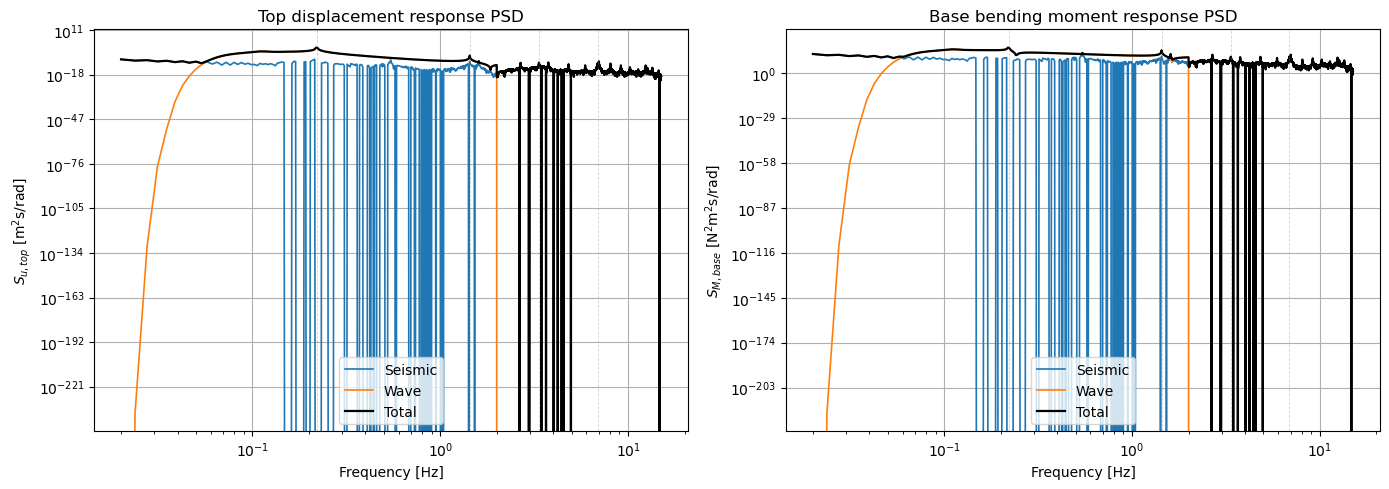

In [13]:
S_u_top_wave_on_seismic_grid = np.interp(omega_seismic, omega_wave, S_u_top_wave, left=0.0, right=0.0)
S_M_base_wave_on_seismic_grid = np.interp(omega_seismic, omega_wave, S_M_base_wave, left=0.0, right=0.0)

S_u_top_total = S_u_top_seismic + S_u_top_wave_on_seismic_grid
S_M_base_total = S_M_base_seismic + S_M_base_wave_on_seismic_grid

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].loglog(f_seismic, S_u_top_seismic, label="Seismic", lw=1.2)
axes[0].loglog(f_seismic, S_u_top_wave_on_seismic_grid, label="Wave", lw=1.2)
axes[0].loglog(f_seismic, S_u_top_total, label="Total", lw=1.6, color="black")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel(r"$S_{u,top}$ [m$^2$s/rad]")
axes[0].set_title("Top displacement response PSD")
axes[0].legend()

axes[1].loglog(f_seismic, S_M_base_seismic, label="Seismic", lw=1.2)
axes[1].loglog(f_seismic, S_M_base_wave_on_seismic_grid, label="Wave", lw=1.2)
axes[1].loglog(f_seismic, S_M_base_total, label="Total", lw=1.6, color="black")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel(r"$S_{M,base}$ [N$^2$m$^2$s/rad]")
axes[1].set_title("Base bending moment response PSD")
axes[1].legend()

for ax in axes:
    for freq_i in f_n:
        ax.axvline(freq_i, color="gray", lw=0.6, ls="--", alpha=0.35)

plt.tight_layout()
plt.show()


## 7. Probability of Exceedance for Part 4.2

For the base stress, the bending stress is obtained from the base bending moment through

$\sigma_{base}(t) = M_{base}(t) / W_1$.

For the top acceleration, the acceleration PSD follows from the displacement PSD as

$S_{a,top}(\omega) = \omega^4 S_{u,top}(\omega)$.

Assuming a normal response $X \sim \mathcal{N}(\mu_X, \sigma_X^2)$, the exceedance of the absolute value beyond a threshold $x_{lim}$ is evaluated as

$P(|X| > x_{lim}) = P(X > x_{lim}) + P(X < -x_{lim})$.

That expression is used below for both the base stress and the top acceleration.


In [17]:
from scipy.stats import norm

sigma_y = 355e6  # Pa = N/m^2
sigma_limit = 0.8 * sigma_y
a_limit = 0.2 * 9.81  # m/s^2
My_limit = sigma_limit * W_t1



mean_base_stress = mean_base_moment / W_t1
var_base_stress_seismic = var_moment_seismic / W_t1**2
var_base_stress_wave = var_moment_wave / W_t1**2
var_base_stress_total = var_moment_total / W_t1**2
std_base_stress_total = np.sqrt(var_base_stress_total)

S_a_top_seismic = omega_seismic**4 * S_u_top_seismic
S_a_top_wave = omega_wave**4 * S_u_top_wave

var_a_top_seismic = float(np.trapezoid(S_a_top_seismic, omega_seismic))
var_a_top_wave = float(np.trapezoid(S_a_top_wave, omega_wave))
var_a_top_total = var_a_top_seismic + var_a_top_wave
std_a_top_total = float(np.sqrt(var_a_top_total))
mean_a_top = 0.0

prob_exceed_moment = float(
    norm.sf(My_limit, loc=mean_base_moment, scale=np.sqrt(var_moment_total))
    + norm.cdf(-My_limit, loc=mean_base_moment, scale=np.sqrt(var_moment_total))
)

prob_exceed_stress = float(
    norm.sf(sigma_limit, loc=mean_base_stress, scale=std_base_stress_total)
    + norm.cdf(-sigma_limit, loc=mean_base_stress, scale=std_base_stress_total)
)
prob_exceed_acc = float(
    norm.sf(a_limit, loc=mean_a_top, scale=std_a_top_total)
    + norm.cdf(-a_limit, loc=mean_a_top, scale=std_a_top_total)
)

part42_results = {
    'base_stress': {
        'mean': float(mean_base_stress),
        'variance_total': float(var_base_stress_total),
        'std_total': float(std_base_stress_total),
        'threshold': float(sigma_limit),
        'probability_abs_exceedance': prob_exceed_stress,
    },
    'top_acceleration': {
        'mean': float(mean_a_top),
        'variance_seismic': float(var_a_top_seismic),
        'variance_wave': float(var_a_top_wave),
        'variance_total': float(var_a_top_total),
        'std_total': float(std_a_top_total),
        'threshold': float(a_limit),
        'probability_abs_exceedance': prob_exceed_acc,
    },
}
print(f'probability_exceedance_moment = {prob_exceed_moment:.6e}')
print('Part 4.2 results')
print('================')
print('Base stress at the OWT base:')
print(f'  mean = {mean_base_stress / 1e6:.6f} MPa')
print(f'  total standard deviation = {std_base_stress_total / 1e6:.6f} MPa')
print(f'  threshold = {sigma_limit / 1e6:.6f} MPa')
print(f'  P(|sigma_base| > 0.8 sigma_y) = {prob_exceed_stress:.6e}')
print()
print('Top acceleration:')
print(f'  mean = {mean_a_top:.6e} m/s^2')
print(f'  variance from seismic = {var_a_top_seismic:.6e} (m/s^2)^2')
print(f'  variance from waves   = {var_a_top_wave:.6e} (m/s^2)^2')
print(f'  total standard deviation = {std_a_top_total:.6e} m/s^2')
print(f'  threshold = {a_limit:.6e} m/s^2 = 0.2 g')
print(f'  P(|a_top| > 0.2 g) = {prob_exceed_acc:.6e}')

S_a_top_wave_on_seismic_grid = np.interp(omega_seismic, omega_wave, S_a_top_wave, left=0.0, right=0.0)
S_a_top_total = S_a_top_seismic + S_a_top_wave_on_seismic_grid



probability_exceedance_moment = 5.041284e-39
Part 4.2 results
Base stress at the OWT base:
  mean = -6.872951 MPa
  total standard deviation = 21.293227 MPa
  threshold = 284.000000 MPa
  P(|sigma_base| > 0.8 sigma_y) = 5.041284e-39

Top acceleration:
  mean = 0.000000e+00 m/s^2
  variance from seismic = 6.665456e-05 (m/s^2)^2
  variance from waves   = 2.538878e-01 (m/s^2)^2
  total standard deviation = 5.039389e-01 m/s^2
  threshold = 1.962000e+00 m/s^2 = 0.2 g
  P(|a_top| > 0.2 g) = 9.887789e-05
